> WTI/Brent Statistical Arbitrage Strategy

Augustin Debove

**Quantitative research project: Implementation of a mean-reversion strategy on energy futures spreads.**

This repository contains a systematic algorithmic trading strategy exploiting the statistical co-integration between **WTI (NYMEX)** and **Brent (ICE)** Crude Oil futures. The project demonstrates a full quantitative pipeline, from raw data ingestion and synchronization to risk-adjusted performance analysis.

#### Technical Highlights
* **Data Engineering and Synchronization:** The framework implements a custom alignment logic to handle asynchronous trading calendars. By reconciling NYMEX and ICE exchange holidays, the backtest eliminates data stale-pricing bias.
* **Mean-Reversion Engine:** Signals are generated via a dynamic Z-Score calculated on a rolling lookback window. This normalizes the spread volatility and identifies statistically significant entry and exit points.
* **Robustness vs. Overfitting:** Parameter selection (window size and thresholds) was conducted using stability cluster analysis rather than raw historical optimization. This ensures higher generalization capabilities on unseen data.
* **Risk Management:** A hard statistical stop-loss is integrated at $|Z| > 3.5$ to protect the portfolio against structural regime shifts or geopolitical shocks.

>> Out-of-Sample Results (Jan 2024 - Feb 2026)
The model was validated on strictly unseen data to confirm its predictive power:
* **Sharpe Ratio:** 2.17
* **Net PnL per Barrel:** $14.60 (inclusive of estimated transaction costs)
* **Execution Logic:** Entry at $|Z| > 1.9$, Mean-reversion exit at $|Z| < 0.5$.

/tmp/ipykernel_23616/3274917961.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(tickers, start="2024-01-01", end="2026-01-01", progress=False)['Close']



TOP 5 BY PROFIT
     Fenetre  Z_score     Profit  Drawdown    Sharpe
246       20     0.55  19.210019 -1.239998  2.064370
251       20     0.80  18.980021 -1.310002  2.051578
252       20     0.85  18.830002 -1.259999  2.035092
243       20     0.40  18.530015 -1.249997  1.989195
244       20     0.45  18.530015 -1.249997  1.989195

TOP 5 BY SHARPE RATIO
     Fenetre  Z_score     Profit  Drawdown    Sharpe
429       30     1.80  15.630005 -1.480005  2.222741
655       45     1.25  17.210014 -1.519997  2.214097
432       30     1.95  15.119997 -1.480005  2.173248
431       30     1.90  15.119997 -1.480005  2.173248
433       30     2.00  15.119997 -1.480005  2.173248


/tmp/ipykernel_23616/3274917961.py:113: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data_oos = yf.download(tickers, start="2024-01-02", end=end_date, progress=False)['Close']



 RESULTS (2024 - Today) 
Net PnL per Barrel : 15.74 $
Sharpe Ratio : 2.10


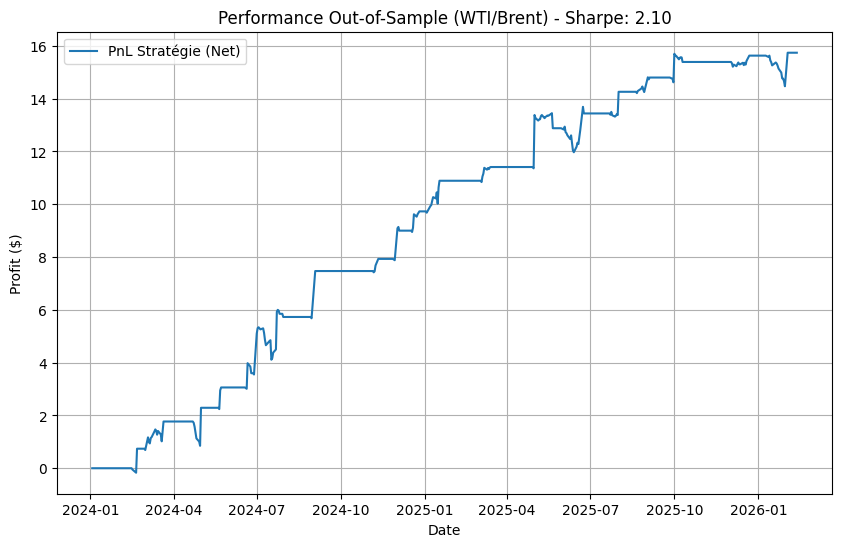

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
########### PART 1 : OPTIMIZATION ###########
tickers = ['CL=F', 'BZ=F']  
raw_data = yf.download(tickers, start="2024-01-01", end="2026-01-01", progress=False)['Close']

data = pd.DataFrame()   # Data Cleaning and Alignment
data['WTI'] = raw_data['CL=F']
data['Brent'] = raw_data['BZ=F']
data.dropna(inplace=True) # Aligning TS: we only keep observations where both NYMEX (WTI) and ICE (Brent) markets are open to avoid non-synchronous data bias.

profit = {}   # Grid search for the best Z-score and the optimal rolling window
sharpe = {}
drawdown = {}

data['spread'] = data['WTI'] - data['Brent'] # Computation of the spread价差
data['spread_diff'] = data['spread'].diff()

transaction_cost = 0.05  # transaction cost per unit, covering spread and transaction fees

# Loop over windows from 5 to 50 days
for i in range(5, 51, 5): 
    mean = data['spread'].rolling(i).mean()   # Pre-calculate rolling stats for this window to speed up the loop
    std = data['spread'].rolling(i).std()
    for k in range(10, 401, 5): # Loop over Z-score thresholds from 0.1 to 4.0
        z = k / 100
        temp_Z = (data['spread'] - mean) / std         # Z-score calculation

        # 1. Initialize signal with NaN
        signal = pd.Series(np.nan, index=data.index)
        
        # 2. Entries
        signal.loc[temp_Z < -z] = 1  # Long Spread
        signal.loc[temp_Z > z] = -1  # Short Spread
        
        # 3. Exits (Mean Reversion)
        # We exit when Z-score comes back to normal (between -0.5 and 0.5)
        signal.loc[temp_Z.abs() < 0.5] = 0
        
        # 4. Stop Loss (Optional but recommended for optimization realism)
        # If Z-score explodes > 4, we cut (Black Swan protection)
        signal.loc[temp_Z.abs() > 4] = 0
        
        # 5. Position Filling
        # We propagate the signal until a new condition (Exit or Reverse) is met
        pos = signal.ffill().fillna(0)
        
        # Computation of the costs
        trades = pos.diff().fillna(0).abs() 
        total_costs = trades * transaction_cost
        
        # Net performance computation
        strat_return = (pos.shift(1) * data['spread_diff']) - total_costs
        
        profit_final = strat_return.sum()
        
        # Storing of the final profit
        profit[(i, z)] = profit_final
        
        # Sharpe Ratio Computation
        if strat_return.std() != 0:
            # Annulized Sharpe
            s = (strat_return.mean() / strat_return.std()) * np.sqrt(252)
        else:
            s = 0
        sharpe[(i, z)] = s

        # Max Drawdown Computation
        equity_curve = strat_return.cumsum()
        max_dd = (equity_curve - equity_curve.cummax()).min()
        drawdown[(i, z)] = max_dd
        
df_opti = pd.Series(profit).reset_index() # Converting profit dictionary to a DataFrame
df_opti.columns = ['Fenetre', 'Z_score', 'Profit']

df_dd = pd.Series(drawdown).reset_index() # Converting Drawdown dictionary to a DataFramee
df_dd.columns = ['Fenetre', 'Z_score', 'Drawdown']
df_opti = df_opti.join(df_dd['Drawdown'])

df_risk = pd.Series(sharpe).reset_index() # Converting Sharpe dictionary to a DataFrame
df_risk.columns = ['Fenêtre', 'Z_score', 'Sharpe']
df_opti = df_opti.join(df_risk['Sharpe'])

# Displaying the best results
print("\nTOP 5 BY PROFIT")
top_5_profit = df_opti.sort_values(by='Profit', ascending=False).head(5)
print(top_5_profit)

print("\nTOP 5 BY SHARPE RATIO")
top_5_sharpe = df_opti.sort_values(by='Sharpe', ascending=False).head(5)
print(top_5_sharpe)

# Automatic link: find the best parameters to use in Part 2
best_row = df_opti.sort_values(by='Sharpe', ascending=False).iloc[0]
best_window = int(best_row['Fenetre'])
best_z_entry = best_row['Z_score']

########### PART 2 : OUT-OF-SAMPLE TEST ###########
# 1. Fetching data that is unknown for the model (Out-of-Sample)????
end_date = datetime.now().strftime('%Y-%m-%d') 
raw_data_oos = yf.download(tickers, start="2024-01-02", end=end_date, progress=False)['Close']

# 2. DATA CLEANING AND ALIGNMENT
data_oos = pd.DataFrame()
data_oos['WTI'] = raw_data_oos['CL=F']
data_oos['Brent'] = raw_data_oos['BZ=F']

# Aligning time series: we only keep observations where both NYMEX (WTI) and ICE (Brent) markets are open.
data_oos.dropna(inplace=True) 

# 3. PARAMETERIZATION: These are automatically assigned from the optimization above
stop_loss_z = 3.5 
transaction_cost = 0.05 

# 4. INDICATORS
data_oos['spread'] = data_oos['WTI'] - data_oos['Brent']
data_oos['spread_diff'] = data_oos['spread'].diff()

# Moving calculations
mean_oos = data_oos['spread'].rolling(window=best_window).mean()
std_oos = data_oos['spread'].rolling(window=best_window).std()
data_oos['z_score'] = (data_oos['spread'] - mean_oos) / std_oos

# Step A: Initialize signal container with NaN (Empty)
data_oos['position'] = np.nan 

# Step B: Entry Signals
# Long if Z < -best_z_entry
data_oos.loc[data_oos['z_score'] < -best_z_entry, 'position'] = 1  
# Short if Z > best_z_entry
data_oos.loc[data_oos['z_score'] > best_z_entry, 'position'] = -1 

# Step C: Exit Conditions (Mean Reversion): Exit when Z returns inside [-0.5, 0.5]. 
data_oos.loc[data_oos['z_score'].abs() < 0.5, 'position'] = 0

# Step D: Stop Loss (Risk Management): Force exit if Z explodes (> 3.5)
data_oos.loc[data_oos['z_score'].abs() > stop_loss_z, 'position'] = 0

# Step E: Propagation (The fix)
data_oos['position'] = data_oos['position'].ffill()

# Step F: Handle the very beginning (before first signal)
data_oos['position'] = data_oos['position'].fillna(0)

# 6. PERFORMANCE CALCULATION
trades_oos = data_oos['position'].diff().fillna(0).abs()
costs_oos = trades_oos * transaction_cost

# PnL strategy (using shift(1) to avoid look-ahead bias)
data_oos['strategy_return'] = (data_oos['position'].shift(1) * data_oos['spread_diff']) - costs_oos

# Cumulative Returns
data_oos['cum_profit'] = data_oos['strategy_return'].cumsum()

# 7. VISUALIZATION & METRICS
final_pnl = data_oos['cum_profit'].iloc[-1]
sharpe_ratio = (data_oos['strategy_return'].mean() / data_oos['strategy_return'].std()) * np.sqrt(252)

print(f"\n RESULTS (2024 - Today) ")
print(f"Net PnL per Barrel : {final_pnl:.2f} $")
print(f"Sharpe Ratio : {sharpe_ratio:.2f}")

# Chart
plt.figure(figsize=(10, 6))
plt.plot(data_oos.index, data_oos['cum_profit'], label='PnL Stratégie (Net)')
plt.title(f"Performance Out-of-Sample (WTI/Brent) - Sharpe: {sharpe_ratio:.2f}")
plt.xlabel("Date")
plt.ylabel("Profit ($)")
plt.legend()
plt.grid(True)
plt.show()
